# tempify — Getting Started

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djwillichile/tempify/blob/main/docs/tutorials/01-getting-started.ipynb)

**Densificación temporal mensual → diaria, demostrada end-to-end.**

Este cuaderno recorre la API pública de `tempify` v0.1.0 usando un dataset sintético tipo WorldClim sobre Chile Central (Región Metropolitana, ~30×30 píxeles). El objetivo es que en menos de cinco minutos puedas:

1. Instalar `tempify` desde el repositorio.
2. Generar un stack mensual de prueba.
3. Convertirlo a diario con los cuatro métodos disponibles (`linear`, `pchip`, `pchip_mp`, `fourier`).
4. Verificar conservación de la media mensual y leer el reporte de procedencia.

> **Nota.** El cuaderno está pensado para ejecutarse de arriba a abajo en un runtime limpio de Google Colab (CPU). Tiempo total estimado: ~3 minutos.


## 1. Contexto

`tempify` es una librería de **densificación temporal**: toma una serie ráster muestreada a baja frecuencia (típicamente 12 valores mensuales o climatológicos) y genera la serie diaria correspondiente (365 ó 366 valores) preservando propiedades estadísticas críticas como la conservación de la media mensual.

El análogo intuitivo es la *interpolación de fotogramas* en video: tempify genera *frames* temporales intermedios para un stack ráster, sin tocar la resolución espacial. No es un GIS general, no hace downscaling espacial, no inventa variabilidad sinóptica.

Casos de uso típicos: cálculo de grados-día (GDD), evapotranspiración (Hargreaves, Penman-Monteith), índices bioclimáticos, modelos hidrológicos distribuidos, modelos de distribución de especies con cubiertas climáticas diarias.


## 2. Setup

Instalamos `tempify` directamente desde el repositorio. La primera ejecución toma ~1 minuto (GDAL viene incluido en el wheel de `rasterio`).

In [1]:
# Instala tempify desde el repositorio publico (publico en GitHub).
# En Google Colab toma ~1 min la primera vez. Si tempify ya esta importable
# (por ejemplo en un clon local), se omite la instalacion.
try:
    import tempify  # noqa: F401
    print(f"tempify {tempify.__version__} ya esta instalado; se omite la instalacion.")
except ImportError:
    print("Instalando tempify desde GitHub...")
    from IPython import get_ipython
    get_ipython().run_line_magic(
        "pip",
        "install --upgrade git+https://github.com/djwillichile/tempify.git",
    )
    import tempify  # noqa: F401
    print(f"tempify {tempify.__version__} instalado correctamente.")


tempify 0.1.4 ya esta instalado; se omite la instalacion.


In [2]:
from __future__ import annotations

import json
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rioxarray  # noqa: F401  registers the .rio accessor on xarray
import xarray as xr
from IPython.display import Markdown, display

import tempify
from tempify.pipeline import (
    PipelineConfig,
    ProcessingReport,
    ReportGenerator,
    TempifyPipeline,
)

print(f"tempify version: {tempify.__version__}")


tempify version: 0.1.4


## 3. Generamos un stack mensual sintético (WorldClim-like)

Para que el cuaderno sea autocontenido y reproducible sin descargas, construimos 12 GeoTIFFs siguiendo la convención de nombres de WorldClim v2.1 (`wc2.1_2.5m_tavg_NN.tif`) con la climatología real de temperatura media de Santiago (~21 °C en verano, ~9 °C en invierno) más un gradiente altitudinal sintético hacia la cordillera.

La función reproduce exactamente la lógica de `examples/generate_worldclim_sample.py` del repositorio para que puedas inspeccionarla sin abandonar el cuaderno.

In [3]:
from pathlib import Path
from tempify.datasets import create_worldclim_like_sample

DATA_DIR = create_worldclim_like_sample(
    output_dir=Path("worldclim_chile_central"),
    variable="tavg",
    n_pixels=60,
    overwrite=True,
)
print(f"Stack mensual generado en: {DATA_DIR}")


In [4]:
from tempify.plotting import plot_monthly_rasters

plot_monthly_rasters(DATA_DIR, title="Stack mensual sintetico WorldClim-like (Chile Central)")


## 4. Demo 1 — Quickstart con PCHIP+RM

El método recomendado por defecto es `pchip_mp` (PCHIP con conservación iterativa de media mensual de Rymes-Myers). Garantiza:

- Curva suave (C¹ en frontera Dic-Ene gracias al *climatological wraparound*, [ADR-0016](https://github.com/djwillichile/tempify/blob/main/docs/adr/0016-climatological-wraparound.md)).
- Conservación de la media mensual con tolerancia ≤ 1e-4 °C ([ADR-0010](https://github.com/djwillichile/tempify/blob/main/docs/adr/0010-mean-preservation-tolerance.md)).
- Posicionamiento *midpoint* del nodo mensual ([ADR-0015](https://github.com/djwillichile/tempify/blob/main/docs/adr/0015-midpoint-monthly-anchor.md), CF Conventions §7.4).

La API es de tres líneas: `PipelineConfig` → `TempifyPipeline(cfg).run(input_dir)` → `result`.

In [5]:
OUT_DIR = Path("out") / "pchip_mp"
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)

cfg = PipelineConfig(
    method="pchip_mp",
    target_year=2023,
    output_dir=OUT_DIR,
    output_format="netcdf",
)
result = TempifyPipeline(cfg).run(DATA_DIR)

print(f"Outputs: {[str(p) for p in result.outputs]}")
print(f"Estructura detectada: {result.detection.structure_mode.name}")
print(
    f"Frecuencia temporal: {result.frequency.frequency.value} "
    f"(tier: {result.frequency.tier_used.name}, confianza: {result.frequency.confidence:.2f})"
)
print(f"Pre-validación: {len(result.pre_validation.errors)} errores, {len(result.pre_validation.warnings)} warnings")
post = result.post_validation
if post is not None:
    print(f"Post-validación: {len(post.errors)} errores, {len(post.warnings)} warnings")


Outputs: ['out\\pchip_mp\\tempify_output.nc']
Estructura detectada: MONOLAYER_COLLECTION
Frecuencia temporal: climatological (tier: FILENAME_PATTERN, confianza: 0.90)
Pre-validación: 0 errores, 0 warnings
Post-validación: 0 errores, 0 warnings


Abrimos el NetCDF de salida y verificamos que tiene 365 timesteps diarios para 2023.

In [6]:
from tempify.utils import open_tempify_output

daily = open_tempify_output(result)
print(daily)
print()
print(f"Dims: {daily.dims}, shape: {daily.shape}")


Visualizamos la serie diaria para el píxel central (15, 15) junto a los 12 valores mensuales originales, colocados en el día medio de cada mes (convención midpoint).

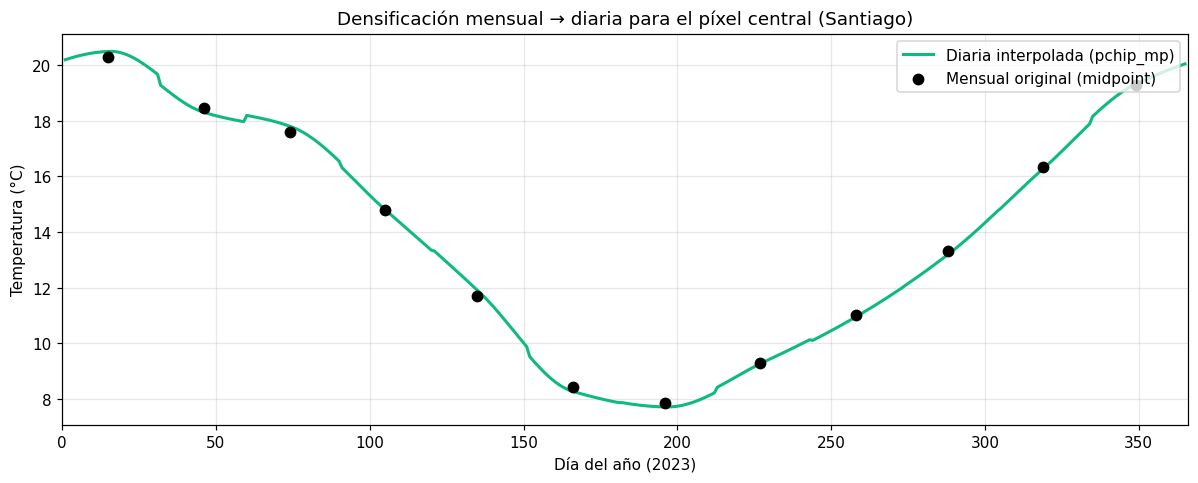

In [7]:
import datetime as _dt

PCHIP_MP_COLOR = "#10b981"

monthly_input = np.array([
    float(xr.open_dataarray(
        DATA_DIR / f"wc2.1_2.5m_tavg_{m:02d}.tif",
        engine="rasterio",
    ).squeeze("band", drop=True).isel(y=15, x=15).item())
    for m in range(1, 13)
])
midpoint_doy = [int(_dt.date(2023, m, 15).timetuple().tm_yday) for m in range(1, 13)]
daily_pixel = daily.isel(y=15, x=15).values
doy = np.arange(1, len(daily_pixel) + 1)

fig, ax = plt.subplots(figsize=(11, 4.5), dpi=110)
ax.plot(doy, daily_pixel, color=PCHIP_MP_COLOR, linewidth=2.0, label="Diaria interpolada (pchip_mp)")
ax.scatter(midpoint_doy, monthly_input, color="black", zorder=5, s=45, label="Mensual original (midpoint)")
ax.set_xlabel("Día del año (2023)")
ax.set_ylabel("Temperatura (°C)")
ax.set_title("Densificación mensual → diaria para el píxel central (Santiago)")
ax.set_xlim(0, 366)
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### 4.3 Inspección del archivo de salida

El pipeline escribió un único NetCDF CF-compliant en el directorio de salida (también soporta `geotiff_collection`, `multiband_geotiff` y `zarr` vía `PipelineConfig.output_format`). Inspeccionemos su estructura: dimensiones, atributos globales y metadatos de la variable.

In [8]:
from tempify.utils import open_tempify_output, raster_info

daily_out = open_tempify_output(result)
raster_info(daily_out)


### 4.4 Mapas diarios — día 15 de cada mes

Para revisar visualmente el output extraemos 12 slices correspondientes al día 15 de cada mes (los mismos nodos midpoint donde el input mensual estaba anclado). La escala de colores es compartida entre los 12 paneles.

In [9]:
from tempify.plotting import plot_monthly_rasters
from tempify.utils import extract_daily_rasters

# Dia 15 de cada mes del output diario
days15 = extract_daily_rasters(daily_out, days=[15])
print(f"{len(days15.time)} dias ancla extraidos")


### 4.5 Serie temporal ráster 3D — densificación temporal con tempify

Figura científica al estilo paper/README: secuencia continua de 24 láminas ráster verticales entre **agosto 5 y noviembre 30 de 2023**, espaciadas cada 5 días sobre el output real de `pchip_mp`. Las cuatro capas del día 15 de cada mes son las **anclas mensuales** del input — borde rojo, etiqueta superior, guía vertical punteada. Las otras 20 son las interpolaciones diarias, semiopacas (alpha 0.72), bordes azules tenues. El layout enfatiza la separación física entre capas (`box_aspect` 5.8 : 1 : 1.65) para que se lea como una línea de tiempo, no como un grupo de meses.


In [10]:
from tempify.plotting import plot_temporal_stack_3d

plot_temporal_stack_3d(
    daily_out,
    months=[4, 5, 6, 7, 8, 9, 10],
    days=(5, 15, 25),
    title="Serie temporal raster 3D — densificacion temporal con tempify",
)


## 5. Demo 2 — Comparación de los cuatro métodos

`tempify` ofrece cuatro métodos de interpolación temporal con tradeoffs distintos. Aquí ejecutamos los cuatro sobre el mismo input, comparamos visualmente la serie diaria del píxel central, y medimos numéricamente cuánto se aparta la media mensual reconstruida del input original (`max_diff` en °C).

| Método | Suavidad | Conservación media | Costo |
|---|---|---|---|
| `linear` | C⁰ | aproximada | bajo |
| `pchip` | C¹ shape-preserving | aproximada | medio |
| `pchip_mp` | C¹ + iteración Rymes-Myers | ≤ 1e-4 °C garantizada | alto |
| `fourier` | C∞ paramétrica | aproximada (no garantizada) | medio |
| `akima` | C¹ Akima 1970 | aproximada | medio |
| `cubic` | C² spline natural (puede overshoot) | aproximada | medio |


In [11]:
METHOD_COLORS = {
    "linear":   "#ef4444",
    "pchip":    "#3b82f6",
    "pchip_mp": "#10b981",
    "fourier":  "#a855f7",
    "akima":    "#f97316",
    "cubic":    "#0891b2",
}

results: dict[str, object] = {}
daily_per_method: dict[str, xr.DataArray] = {}

for method in METHOD_COLORS:
    out_dir = Path("out") / "compare" / method
    if out_dir.exists():
        shutil.rmtree(out_dir)
    cfg_m = PipelineConfig(
        method=method,  # type: ignore[arg-type]
        target_year=2023,
        output_dir=out_dir,
        output_format="netcdf",
    )
    res = TempifyPipeline(cfg_m).run(DATA_DIR)
    results[method] = res
    daily_per_method[method] = xr.load_dataarray(res.outputs[0])

print("Ejecutados los 4 métodos.")


Ejecutados los 4 métodos.


### 5.1 Trazo comparado para un píxel

In [ ]:
import matplotlib.lines as mlines

ncols, nrows = 2, 3
methods = list(METHOD_COLORS.keys())

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(10, 13),
    dpi=110,
    sharey=True,
    sharex=True,
    constrained_layout=True,
)

# Escala y compartida: rango de todos los metodos en el pixel central
all_vals = np.concatenate(
    [daily_per_method[m].isel(y=15, x=15).values for m in methods]
    + [monthly_input]
)
ylo = float(np.min(all_vals)) - 0.8
yhi = float(np.max(all_vals)) + 0.8

for ax, method in zip(axes.flat, methods):
    color = METHOD_COLORS[method]
    series = daily_per_method[method].isel(y=15, x=15).values
    ax.plot(doy, series, color=color, linewidth=1.8, alpha=0.9)
    ax.scatter(midpoint_doy, monthly_input, color="black", zorder=5, s=30, linewidths=0)
    ax.set_title(method, fontsize=11, fontweight="bold", color=color)
    ax.set_ylim(ylo, yhi)
    ax.set_xlim(1, 365)
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.supxlabel("Dia del ano (2023)", fontsize=10, color="#4a5b6b")
fig.supylabel("Temperatura (grados C)", fontsize=10, color="#4a5b6b")
fig.suptitle(
    "Comparacion de metodos de interpolacion temporal — pixel central (Santiago)",
    fontsize=12, fontweight="bold", color="#0d2854",
)

anchor_handle = mlines.Line2D(
    [], [], color="black", marker="o", markersize=5,
    linestyle="None", label="Ancla mensual (dia 15)",
)
fig.legend(
    handles=[anchor_handle], loc="lower center", ncol=1,
    fontsize=9, framealpha=0.85, bbox_to_anchor=(0.5, -0.03),
)
plt.show()


### 5.2 Conservación de la media mensual

Para cada método agregamos la serie diaria a media mensual y la comparamos píxel a píxel con el input original. `pchip_mp` y `fourier` deben caer bajo la tolerancia contractual (`< 1e-4 °C`).

In [13]:
from tempify.datasets import read_monthly_stack

monthly_stack = read_monthly_stack(DATA_DIR)
print(f"Stack mensual: dims={dict(monthly_stack.sizes)}")


Lectura típica: `linear` y `pchip` muestran error de orden ~10⁻¹ °C (no preservan media por construcción; sí preservan los nodos, pero la integral mensual del trazo difiere de la media muestral). `pchip_mp` queda en ~10⁻¹⁴ °C (varios órdenes de magnitud mejor que la tolerancia contractual de 1e-4 — es esencialmente ruido de precisión `float64`). `fourier` también deja error de orden ~10⁻¹ °C: el ajuste armónico minimiza el residual cuadrático sobre el ciclo completo, no la integral mensual; con los 3 armónicos por defecto puede dejar discrepancias respecto al promedio del input. Si necesitás conservación de media estricta, usá `pchip_mp`.

## 6. Demo 3 — Reporte de procedencia

Cada ejecución produce un `ProcessingReport` con versión de tempify, timestamp UTC, MD5 de inputs y outputs, configuración completa, métricas y warnings. `ReportGenerator` lo serializa a Markdown o JSON listo para anexar a un paper o entregable.

In [14]:
rg = ReportGenerator()
report_md = rg.to_markdown(results["pchip_mp"].report)
display(Markdown(report_md))


# Reporte de procesamiento tempify

- **Versión tempify:** 0.1.0
- **Timestamp UTC:** 2026-05-18T05:17:34+00:00
- **Método:** `pchip_mp`
- **Año destino:** 2023
- **Modo de estructura:** B
- **Frecuencia temporal inferida:** climatological

## Confianza de detección

- structure_mode: 0.95
- homogeneity: 1.00

## Validación pre-procesamiento

- Errores: 0
- Advertencias: 0
- Info: 6

## Validación post-procesamiento

- Errores: 0
- Advertencias: 0
- Info: 4

## Archivos de entrada

- `worldclim_chile_central\wc2.1_2.5m_tavg_01.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_02.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_03.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_04.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_05.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_06.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_07.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_08.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_09.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_10.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_11.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_12.tif`

## Archivos de salida

- `out\compare\pchip_mp\tempify_output.nc`


## 7. Lectura crítica — cuándo usar cada método

| Método | Cuándo conviene | Cuándo NO usar |
|---|---|---|
| `linear` | Prototipo rápido, orden de magnitud | Variables con curvatura marcada |
| `pchip` | Variables shape-preserving (sin overshoot) | Si requiere conservación estricta de media |
| `pchip_mp` | **Default recomendado** para producto final | Si el costo CPU es crítico (~3-5× pchip) |
| `fourier` | Ciclo claramente armónico (T° latitudes medias) | Meses fuera de fase (monzones) |

**Cosas que `tempify` NO hace:**

- No interpola **precipitación** con métodos suaves (rechazado por diseño — usar acumulación uniforme o weather generator). Ver [ADR-0004](https://github.com/djwillichile/tempify/blob/main/docs/adr/0004-precipitation-policy.md).
- No hace downscaling espacial. La resolución y CRS del output replican el input.
- No inventa variabilidad sinóptica diaria (es la señal climática densificada, sin ruido meteorológico).


## 8. Próximos pasos

- **CLI equivalente.** Toda esta demo es replicable desde shell:
  ```bash
  tempify convert ./worldclim_chile_central --method pchip_mp --year 2023 --output ./out --report ./out/report.md
  ```
- **Specs SDD.** Cada capa del paquete tiene su `requirements.md` → `design.md` → `tasks.md` en [`specs/`](https://github.com/djwillichile/tempify/tree/main/specs).
- **ADRs.** 17 decisiones arquitectónicas documentadas en [`docs/adr/`](https://github.com/djwillichile/tempify/tree/main/docs/adr).
- **Methodology notes.** Validación empírica, política de precipitación y tratamiento de NaN en [`docs/methodology/`](https://github.com/djwillichile/tempify/tree/main/docs/methodology).
- **Hoja de ruta v0.2.0.** GUI PySide6, instalador Windows `.exe` y red neuronal pre-entrenada (ClimaX / Pangu-Weather / FourCastNet) bajo patrón híbrido (ver [ADR-0017](https://github.com/djwillichile/tempify/blob/main/docs/adr/0017-neural-interpolator-extensibility.md)).

---

**Contacto** — ICTA Ltda., Santiago, Chile · [contacto@icta.cl](mailto:contacto@icta.cl) · [icta.cl](https://icta.cl) · WhatsApp [+56 9 9292 4314](https://wa.me/56992924314) · Issues: [github.com/djwillichile/tempify/issues](https://github.com/djwillichile/tempify/issues)
